<a href="https://colab.research.google.com/github/tim-parisi/data-science-project/blob/main/Data_Science_Project_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project

Team Members:
Ignacio, Timothy, Jamie, Megan

...




# Data Exploration and Cleaning

In [6]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Gathering Datasets

In [7]:
first_student = pd.read_csv('first_student.csv')
second_student = pd.read_csv('second_student.csv')
third_student = pd.read_csv('third_student.csv')
first_dummy = pd.read_csv('first_dummy.csv')
second_dummy = pd.read_csv('second_dummy.csv')
third_dummy = pd.read_csv('third_dummy.csv')

#### PCA

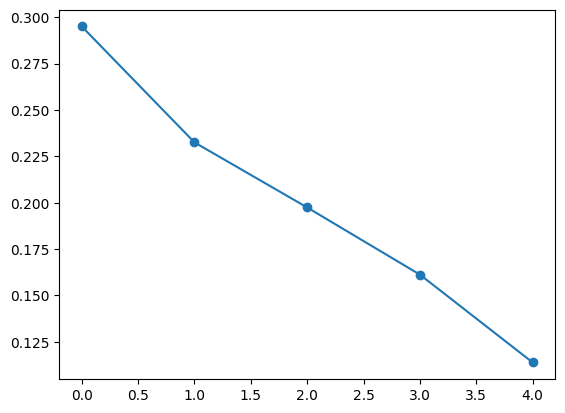

Total variance with 4 components: 0.8861%


In [8]:
scaler = StandardScaler()
pca = PCA(n_components=5)
X_scaled = scaler.fit_transform(first_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 4
pca_1 = PCA(n_components=total_components)
X_pca_1 = pca_1.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_1.explained_variance_ratio_.sum():.4f}%')

#### PCA

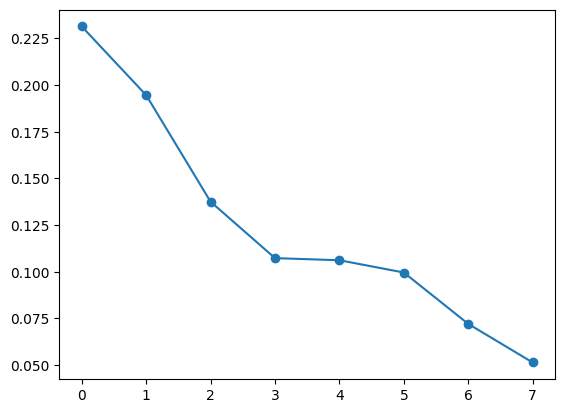

Total variance with 6 components: 0.8765%


In [9]:
scaler = StandardScaler()
pca = PCA(n_components=8)
X_scaled = scaler.fit_transform(second_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 6
pca_2 = PCA(n_components=total_components)
X_pca_2 = pca_2.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_2.explained_variance_ratio_.sum():.4f}%')

#### PCA

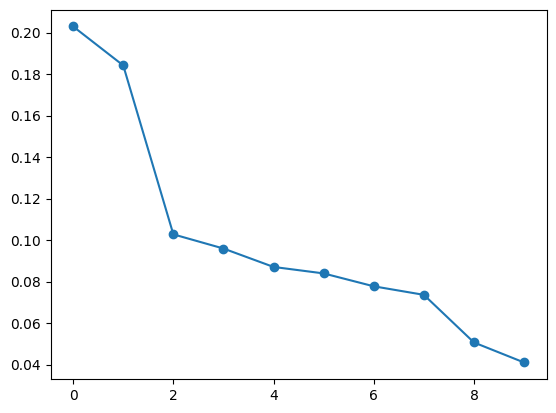

Total variance with 7 components: 0.8347%


In [10]:
scaler = StandardScaler()
pca = PCA(n_components=10)
X_scaled = scaler.fit_transform(third_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 7
pca_3 = PCA(n_components=total_components)
X_pca_3 = pca_3.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_3.explained_variance_ratio_.sum():.4f}%')

# Unit Tests

# Heatmap/Correlation Matrix




# Modeling

### Visualizing Datasets

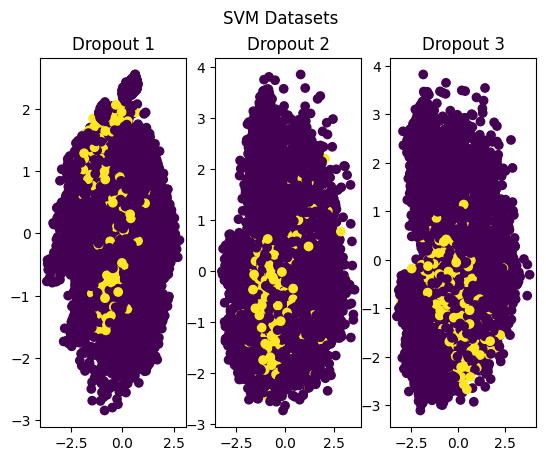

In [11]:
datasets = {1: (X_pca_1, first_dummy['dropout']), 2: (X_pca_2, second_dummy['dropout']), 3: (X_pca_3, third_dummy['dropout'])}
graphing_datasets = X_pca_1[:,0], X_pca_2[:1]
fig, axes = plt.subplots(1, 3)
fig.suptitle('SVM Datasets')
for ix, (X, y) in enumerate(datasets.values(), start=0):
    axes[ix].scatter(X[:,0], X[:,1], c=y)
    axes[ix].set_title(f'Dropout {ix+1}')
plt.show()

##Model 2: KNN

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


Dataset 1
Best k: 11
Accuracy: 0.95
Precision: 0.76
Recall (Sensitivity): 0.57
F1-Score: 0.65


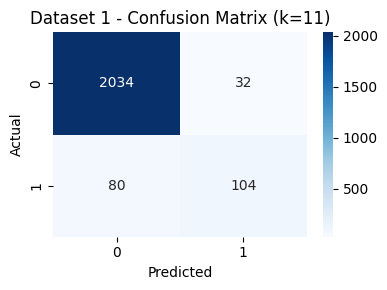

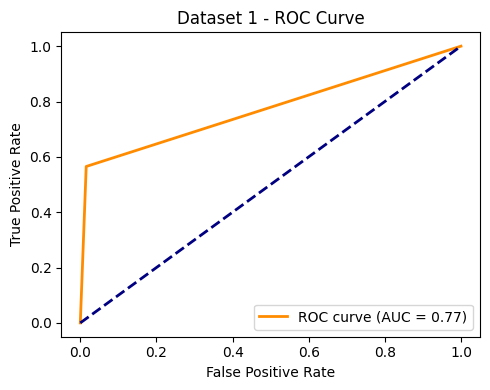


Dataset 2
Best k: 11
Accuracy: 0.93
Precision: 0.73
Recall (Sensitivity): 0.71
F1-Score: 0.72


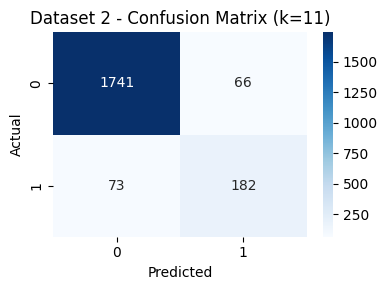

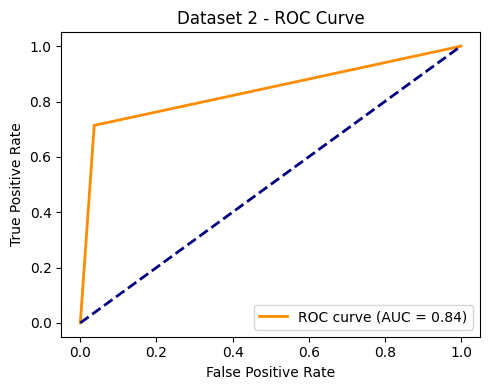


Dataset 3
Best k: 11
Accuracy: 0.91
Precision: 0.62
Recall (Sensitivity): 0.42
F1-Score: 0.50


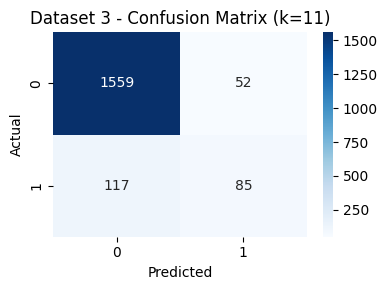

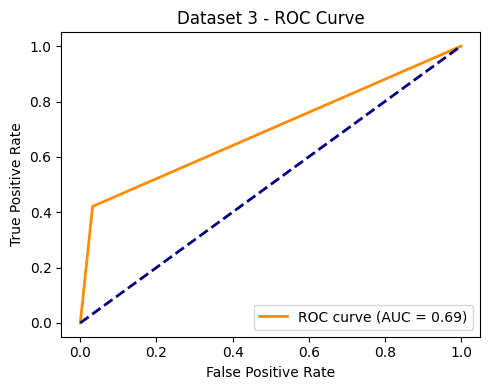

In [13]:
for ix, (X, y) in enumerate(datasets.values(), start=1):
    print(f"\nDataset {ix}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Grid search for best k
    param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11]}
    knn = KNeighborsClassifier()
    grid_search = GridSearchCV(knn, param_grid, cv=5)
    grid_search.fit(X_train, y_train)

    # Best k and model
    best_k = grid_search.best_params_['n_neighbors']
    best_model = grid_search.best_estimator_

    # Predictions
    y_pred = best_model.predict(X_test)

    print(f"Best k: {best_k}")

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision:.2f}")

    # Calculate recall (sensitivity)
    recall = recall_score(y_test, y_pred)
    print(f"Recall (Sensitivity): {recall:.2f}")

    # Calculate F1-score
    f1 = f1_score(y_test, y_pred)
    print(f"F1-Score: {f1:.2f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Dataset {ix} - Confusion Matrix (k={best_k})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Dataset {ix} - ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
